In [1]:
# ============================================================
# Setup
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

np.random.seed(0)


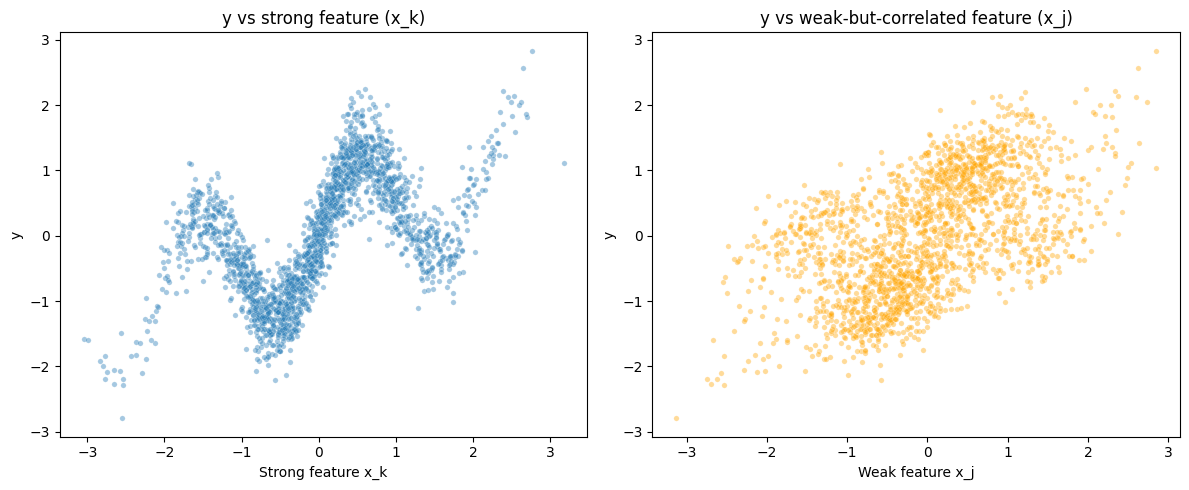

In [2]:
# ============================================================
# Generate correlated features
# ============================================================

n = 2000
rho = 0.9  # correlation between strong and weak feature

# Strong feature
x_k = np.random.randn(n)

# Weak but correlated feature
x_j = rho * x_k + np.sqrt(1 - rho**2) * np.random.randn(n)

# Noise features
X_noise = np.random.randn(n, 8)

# Response: strong + weak + noise
y = np.sin(3*x_k) + 0.5*x_j + 0.3*np.random.randn(n)

# Combine features
X = np.column_stack([x_k, x_j, X_noise])
feature_names = ["strong_k", "weak_j"] + [f"noise_{i}" for i in range(8)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

plt.figure(figsize=(12,5))

# -----------------------------------------
# Plot y vs strong feature x_k
# -----------------------------------------
plt.subplot(1,2,1)
sns.scatterplot(x=x_k, y=y, s=15, alpha=0.4)
plt.xlabel("Strong feature x_k")
plt.ylabel("y")
plt.title("y vs strong feature (x_k)")

# -----------------------------------------
# Plot y vs weak-but-correlated feature x_j
# -----------------------------------------
plt.subplot(1,2,2)
sns.scatterplot(x=x_j, y=y, s=15, alpha=0.4, color="orange")
plt.xlabel("Weak feature x_j")
plt.ylabel("y")
plt.title("y vs weak-but-correlated feature (x_j)")

plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# Bagging (q = p)
# ============================================================

bag = RandomForestRegressor(
    n_estimators=300,
    max_features=X.shape[1],  # q = p
    random_state=0
)
bag.fit(X_train, y_train)

bag_importances = pd.Series(bag.feature_importances_, index=feature_names)
bag_importances


strong_k    0.859089
weak_j      0.064965
noise_0     0.008867
noise_1     0.009243
noise_2     0.009639
noise_3     0.009596
noise_4     0.009441
noise_5     0.007994
noise_6     0.010844
noise_7     0.010322
dtype: float64

In [18]:
# ============================================================
# Random Forest with small q
# ============================================================

rf_small_q = RandomForestRegressor(
    n_estimators=300,
    max_features=1,   # small q
    random_state=0
)
rf_small_q.fit(X_train, y_train)

rf_small_q_importances = pd.Series(rf_small_q.feature_importances_, index=feature_names)
rf_small_q_importances


strong_k    0.337271
weak_j      0.236340
noise_0     0.052170
noise_1     0.052978
noise_2     0.051030
noise_3     0.054132
noise_4     0.053347
noise_5     0.053700
noise_6     0.054057
noise_7     0.054974
dtype: float64

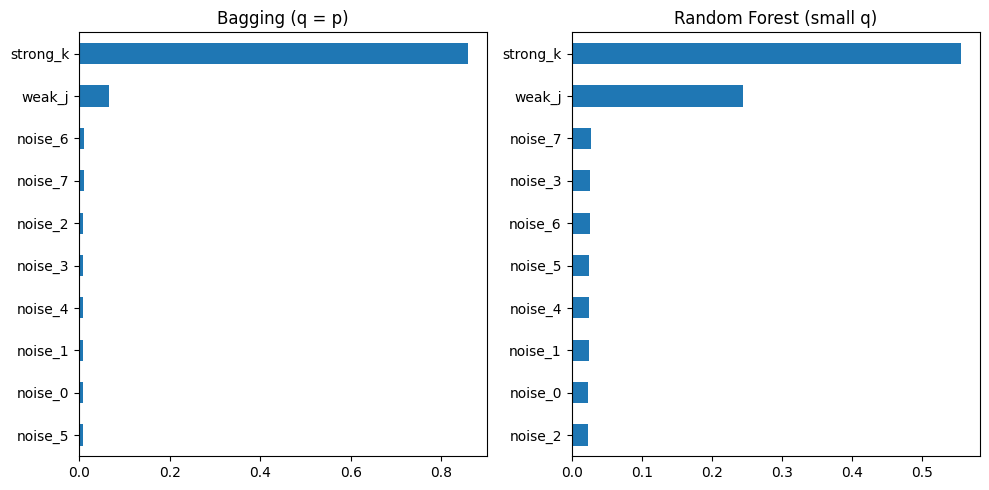

In [5]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
bag_importances.sort_values().plot(kind='barh')
plt.title("Bagging (q = p)")

plt.subplot(1,2,2)
rf_small_q_importances.sort_values().plot(kind='barh')
plt.title("Random Forest (small q)")

plt.tight_layout()
plt.show()
